# 🧱 Texture & Surface Analysis (GLCM + LBP)
### Developer: Wong Kai Bin

This notebook extracts **texture features** from the preprocessed mango images and classifies them into three ripeness stages: **unripe**, **fully_ripe** and **overripe**.

**Pipeline at a glance:**

1. Load the background-removed 640×640 images from `cleaned_data/`.
2. For every image: convert to grayscale → build a fruit mask → extract **GLCM** features (Contrast, Correlation, Energy, Homogeneity) → extract **LBP** features (Mean, Variance, Entropy).
3. Save all features into one CSV (`output/texture_based/texture_features.csv`).
4. Classify with **Random Forest**, **SVM** and **KNN**, compare the results, and save the best model and the evaluation images.

Only classical image processing (OpenCV + scikit-image) and scikit-learn are used — no deep learning.

### Step 1: Imports & Configuration

| Library | Used for |
|---|---|
| `cv2` (OpenCV) | reading images, grayscale conversion, masking |
| `skimage.feature` | `graycomatrix` / `graycoprops` (GLCM), `local_binary_pattern` (LBP) |
| `numpy` / `pandas` | maths and tabular data |
| `sklearn` | classifiers (RF, SVM, KNN), scaling, metrics |
| `tqdm` | progress bar |
| `joblib` | saving the trained model |

**Key parameters (these go into your report):**

| Parameter | Value | Reason |
|---|---|---|
| GLCM distance | 1 pixel | captures fine local texture |
| GLCM directions | 0°, 45°, 90°, 135° | averaged → rotation invariant |
| LBP radius | 1 | smallest neighbourhood, fine detail |
| LBP neighbours | 8 | standard for radius 1 |
| LBP method | uniform | robust, only 10 codes for P=8 |

In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score)

import joblib
from tqdm.auto import tqdm

# ---------------------------------------------------------------------------
# Paths - robust against the kernel being started from any folder
# ---------------------------------------------------------------------------
# When the kernel runs from the notebooks/ folder, cwd is the notebook dir.
# We try a couple of candidates and use the first one that actually has data.
CWD = Path(os.path.abspath('')).resolve()
candidates = [CWD / '..' / 'cleaned_data',   # launched from notebooks/
              CWD / 'cleaned_data']          # launched from repo root
ROOT = next((p for p in candidates if (p / 'train').exists()), None)
if ROOT is None:
    raise FileNotFoundError(
        "cleaned_data not found. Looked in:\n"
        + "\n".join(f"  - {p}" for p in candidates)
    )
ROOT = ROOT.resolve()

CLASSES = ['unripe', 'fully_ripe', 'overripe']
LABEL_MAP = {'unripe': 0, 'fully_ripe': 1, 'overripe': 2}

# ---------------------------------------------------------------------------
# Feature-extraction parameters (documented in Step 1)
# ---------------------------------------------------------------------------
GLCM_DISTANCES = [1]
GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]  # 0, 45, 90, 135 degrees
LBP_P, LBP_R = 8, 1

FEATURE_COLS = ['glcm_contrast', 'glcm_correlation', 'glcm_energy',
                'glcm_homogeneity', 'lbp_mean', 'lbp_variance', 'lbp_entropy']

OUTPUT_DIR = (ROOT.parent / 'output' / 'texture_based').resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data root : {ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Data root : C:\repository\mango-ripeness-grading\cleaned_data
Output dir: C:\repository\mango-ripeness-grading\output\texture_based


### Step 2: Fruit Mask Extraction

The preprocessing pipeline removed the background, so the background pixels are **black (value 0)**. If we computed GLCM over the whole 640×640 image, the large black region would dominate the co-occurrence counts and hide the fruit's real texture.

The mask simply marks every pixel that is **not black** as *fruit* (1) and everything else as *background* (0). GLCM and LBP are then computed only on fruit pixels.

In [2]:
def get_fruit_mask(img, thresh=30):
    """Binary mask: 1 where the pixel is fruit, 0 where it is black background."""
    # Sum over the 3 colour channels; near-black background gives a small sum
    return (img.sum(axis=2) > thresh).astype(np.uint8)

### Step 3: GLCM Features (Contrast, Correlation, Energy, Homogeneity)

A **Gray Level Co-occurrence Matrix** counts how often a pair of grey levels `(i, j)` appears as neighbours separated by a fixed offset. Here the offset is **1 pixel**, and we count in four directions: **0°, 45°, 90° and 135°**. Averaging the four directions makes the features **rotation-invariant** — the result is the same no matter how the mango is rotated in the image.

Four features are derived from the matrix:

- **Contrast** — Σ (i−j)² · P(i,j): how much grey levels differ between neighbours → surface *roughness*.
- **Correlation** — how linearly dependent each pixel is on its neighbour → texture *consistency*.
- **Energy** — Σ P(i,j)²: textural *uniformity*; smooth uniform surfaces score high.
- **Homogeneity** — Σ P(i,j) / (1 + |i−j|): how close co-occurrences are to the diagonal → *smoothness*.

**Background handling:** because the background is grey level 0, we zero-out row/column 0 of the matrix and re-normalise it, so the black background does not skew the features.

In [3]:
def extract_glcm_features(gray, mask):
    """GLCM features (Contrast, Correlation, Energy, Homogeneity) of the fruit.

    Parameters
    ----------
    gray : 2D uint8 grayscale image
    mask : 2D uint8 binary mask (fruit = 1)
    """
    # Keep fruit pixels, set the black background to grey level 0
    masked_gray = cv2.bitwise_and(gray, gray, mask=mask)

    # Co-occurrence matrix: 1-pixel distance, 4 directions, 256 grey levels
    glcm = graycomatrix(masked_gray, distances=GLCM_DISTANCES,
                        angles=GLCM_ANGLES, levels=256,
                        symmetric=True, normed=True)

    # Remove co-occurrences that involve the background level (0),
    # then re-normalise so the probabilities still sum to 1.
    glcm_fruit = glcm.copy()
    glcm_fruit[0, :, :, :] = 0   # row 0: i = background
    glcm_fruit[:, 0, :, :] = 0   # column 0: j = background
    total = np.sum(glcm_fruit, axis=(0, 1), keepdims=True)

    if np.all(total == 0):
        # No fruit pixels found - keep the original matrix as a fallback
        glcm_norm = glcm
    else:
        glcm_norm = glcm_fruit / total

    # Average each property over the four directions
    return {
        'glcm_contrast':    float(np.mean(graycoprops(glcm_norm, 'contrast'))),
        'glcm_correlation': float(np.mean(graycoprops(glcm_norm, 'correlation'))),
        'glcm_energy':      float(np.mean(graycoprops(glcm_norm, 'energy'))),
        'glcm_homogeneity': float(np.mean(graycoprops(glcm_norm, 'homogeneity'))),
    }

### Step 4: LBP Features (Mean, Variance, Entropy)

A **Local Binary Pattern** describes the local surface structure around each pixel. For radius **R=1**, each pixel has **P=8** neighbours on a circle. Each neighbour is compared with the centre pixel: if neighbour ≥ centre → bit **1**, otherwise bit **0**. The 8 bits form a code (0–255).

We use the **uniform** variant: only patterns with at most two 0↔1 transitions are kept. This is more robust to noise and reduces the number of possible codes to just **10** for P=8.

From the LBP-transformed fruit region we compute three statistics:

- **Mean** — the average LBP code in the fruit.
- **Variance** — the spread of the local patterns → texture roughness.
- **Entropy** — −Σ p·log₂(p) over the pattern histogram → texture *complexity*. A wrinkled, spotted overripe skin has a very different entropy than a smooth unripe skin.

In [4]:
def extract_lbp_features(gray, mask, P=LBP_P, R=LBP_R):
    """LBP statistics (Mean, Variance, Entropy) of the fruit region."""
    # Uniform LBP: only patterns with <= 2 transitions are kept
    lbp = local_binary_pattern(gray, P=P, R=R, method='uniform')

    # Keep only the fruit pixels (the black background is excluded)
    fruit_lbp = lbp[mask > 0]
    if len(fruit_lbp) == 0:
        return {'lbp_mean': 0.0, 'lbp_variance': 0.0, 'lbp_entropy': 0.0}

    lbp_mean = float(np.mean(fruit_lbp))
    lbp_var = float(np.var(fruit_lbp))

    # Shannon entropy of the normalised histogram of LBP codes.
    # For uniform LBP with P=8 there are 10 codes (0..9).
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(fruit_lbp, bins=n_bins, range=(0, n_bins),
                           density=True)
    hist = hist[hist > 0]                      # drop empty bins (log(0) invalid)
    lbp_entropy = float(-np.sum(hist * np.log2(hist)))

    return {'lbp_mean': lbp_mean, 'lbp_variance': lbp_var, 'lbp_entropy': lbp_entropy}

### Step 5: Combined Feature Extraction Pipeline

`texture_pipeline` chains everything for one image: mask → grayscale → GLCM → LBP, and returns one dict of 7 features plus the mask and grayscale image (the latter two are useful for visualisation).

In [5]:
def texture_pipeline(img):
    """Extract all 7 texture features from one BGR image.

    Returns
    -------
    feats : dict with the 7 GLCM + LBP features
    mask  : fruit mask (for visualisation)
    gray  : grayscale image (for visualisation)
    """
    mask = get_fruit_mask(img)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    feats = {**extract_glcm_features(gray, mask), **extract_lbp_features(gray, mask)}
    return feats, mask, gray

### Step 6: Visual Inspection on Sample Images

Before extracting features from all images, look at one example per class: original, grayscale, LBP map and LBP histogram. This confirms that the texture patterns really do differ between ripeness stages.

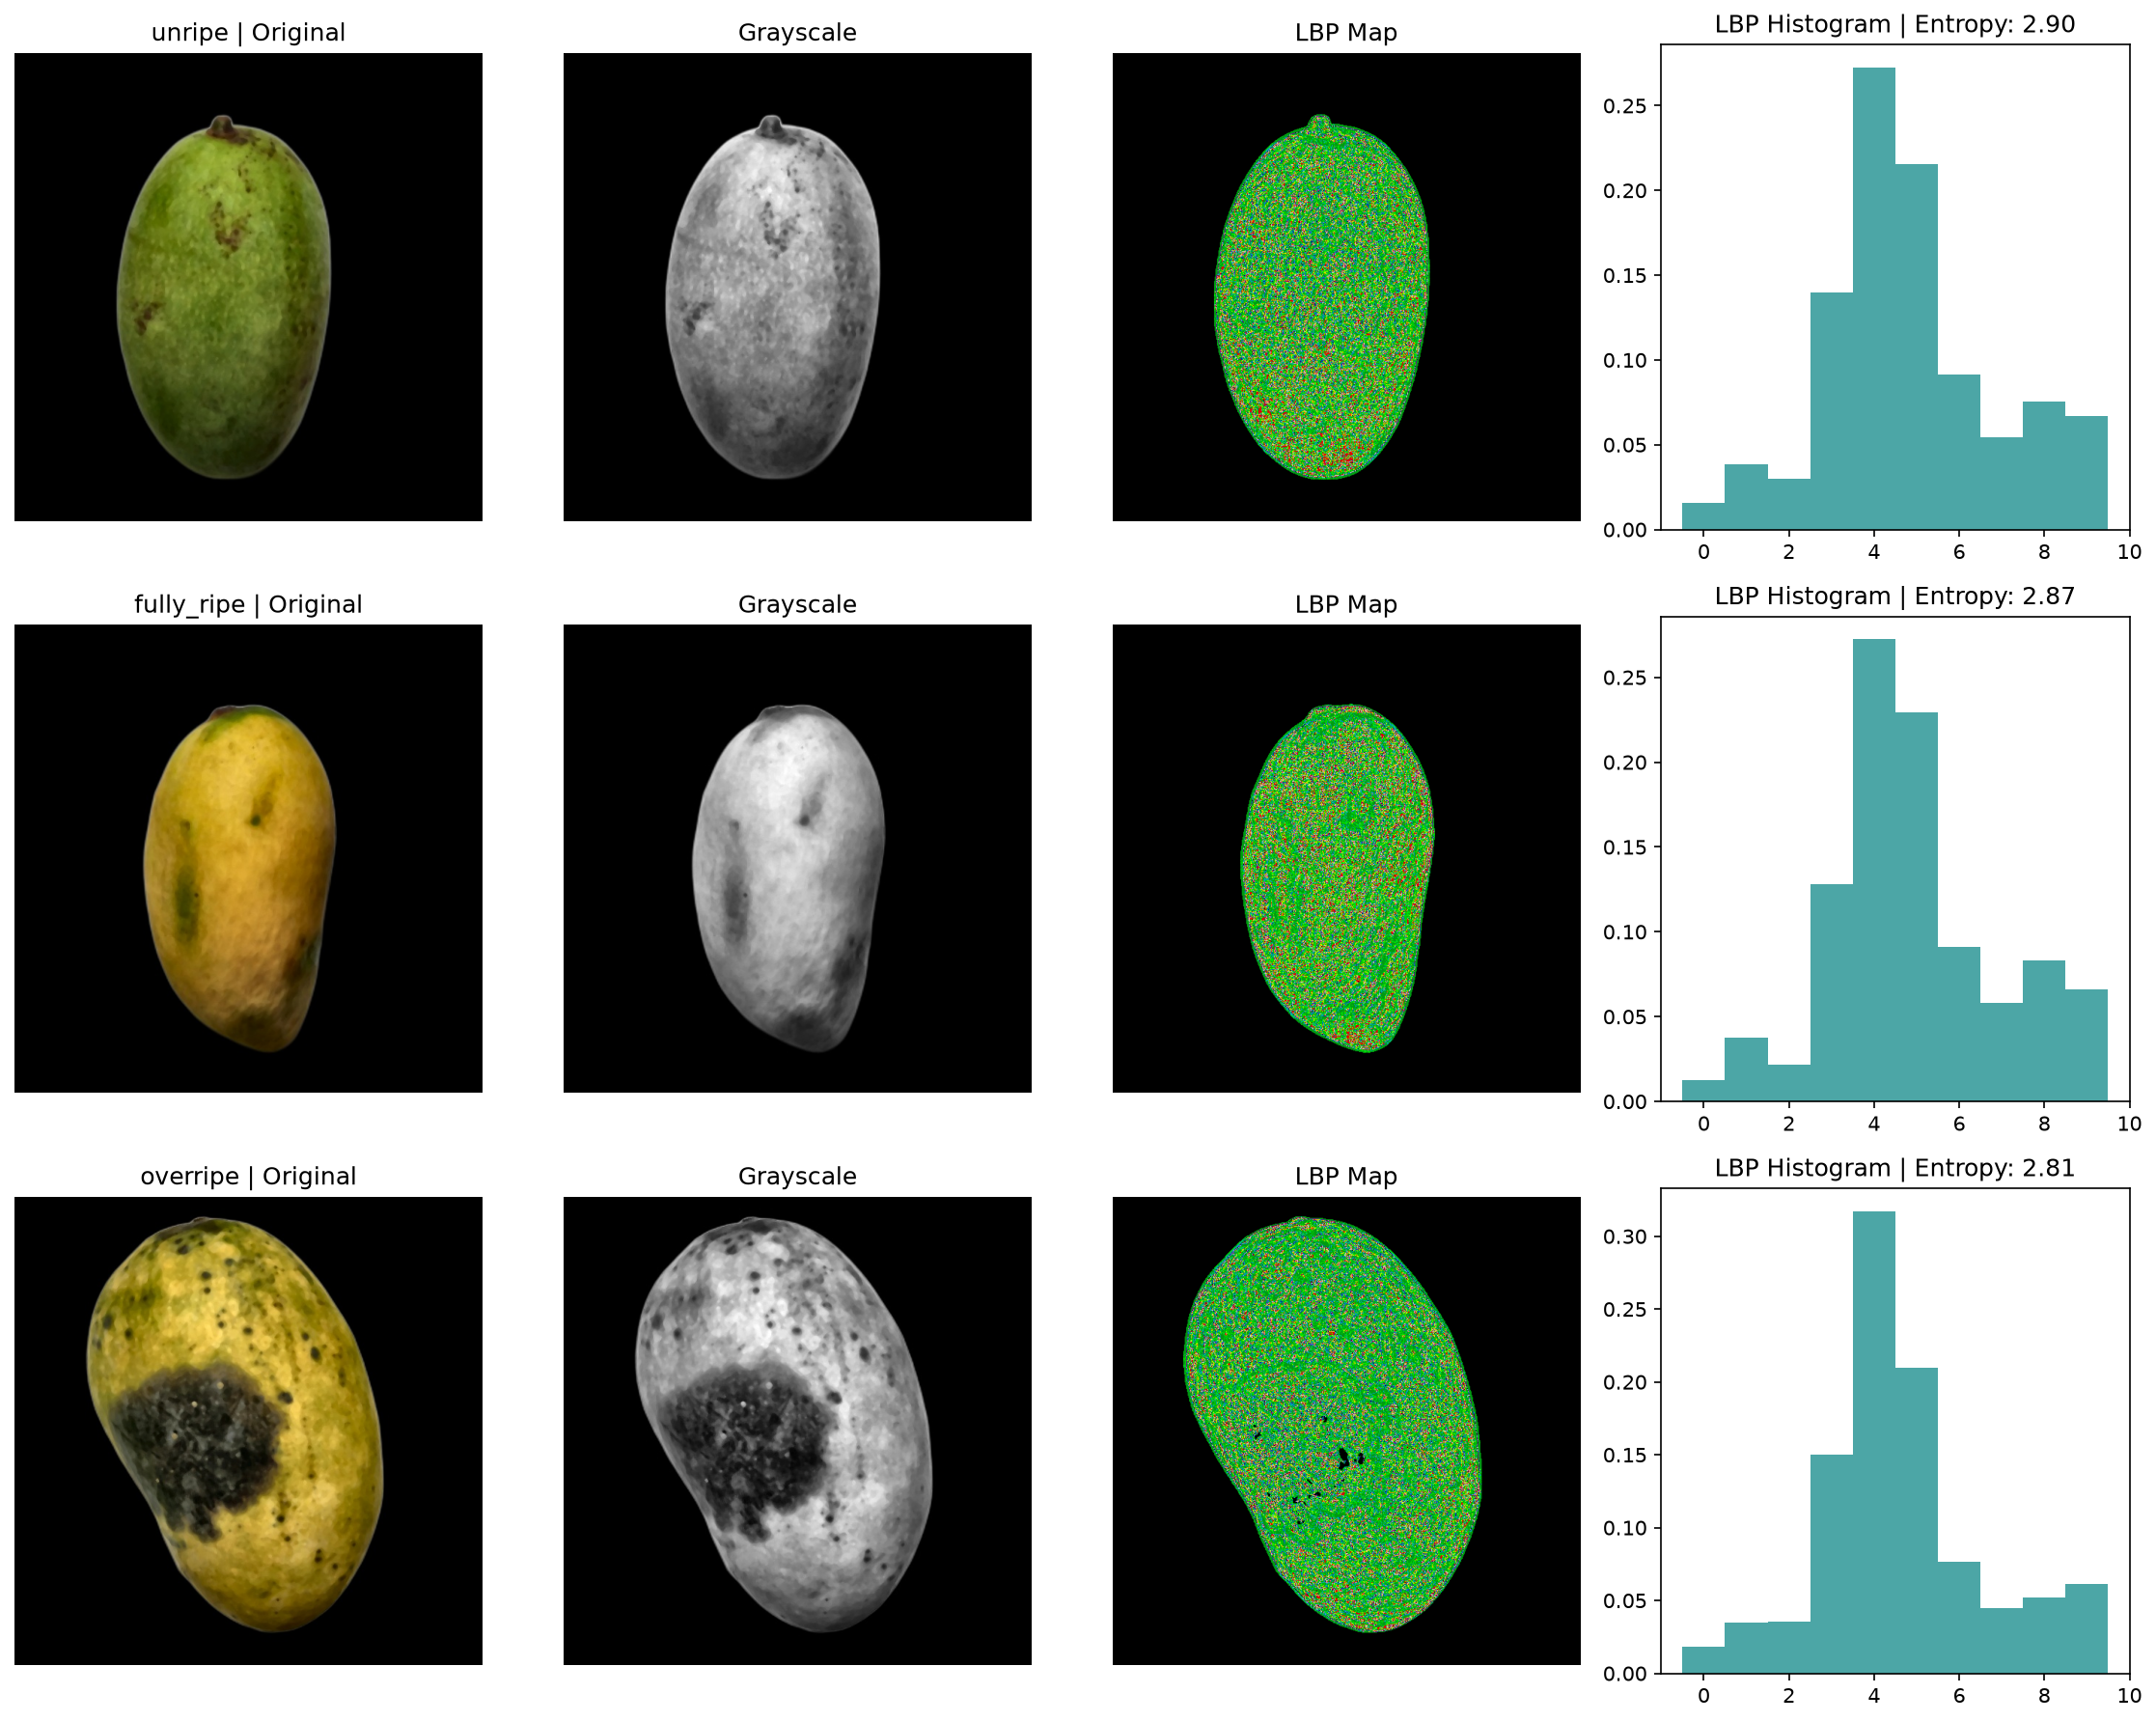

In [6]:
# One example image per class, visualised in 4 ways
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(15, 4 * len(CLASSES)))

for r, cls in enumerate(CLASSES):
    img_paths = sorted((ROOT / 'train' / cls).glob('*.jpg'))
    if not img_paths:
        continue
    img = cv2.imread(str(img_paths[0]))
    feats, mask, gray = texture_pipeline(img)

    # Recompute the LBP map for display (same parameters as extraction)
    lbp_img = local_binary_pattern(gray, P=LBP_P, R=LBP_R, method='uniform')
    lbp_masked = np.where(mask > 0, lbp_img, 0)

    axes[r, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[r, 0].set_title(f'{cls} | Original')
    axes[r, 0].axis('off')

    axes[r, 1].imshow(gray, cmap='gray')
    axes[r, 1].set_title('Grayscale')
    axes[r, 1].axis('off')

    axes[r, 2].imshow(lbp_masked, cmap='nipy_spectral')
    axes[r, 2].set_title('LBP Map')
    axes[r, 2].axis('off')

    # Histogram with integer-centred bins (LBP codes 0..9)
    fruit_lbp = lbp_img[mask > 0]
    axes[r, 3].hist(fruit_lbp, bins=np.arange(-0.5, 10.5, 1), density=True,
                    color='teal', alpha=0.7)
    axes[r, 3].set_title(f'LBP Histogram | Entropy: {feats["lbp_entropy"]:.2f}')

plt.tight_layout()
plt.show()

### Step 7: Build the Feature Dataset (Train & Test)

Loop over the six folders (`train|test` × `unripe|fully_ripe|overripe`) and extract the 7 features from every image. Each image becomes one row with columns:

`filename`, `class`, `train_or_test`, `glcm_contrast`, `glcm_correlation`, `glcm_energy`, `glcm_homogeneity`, `lbp_mean`, `lbp_variance`, `lbp_entropy`

- `tqdm` shows a progress bar.
- A `try/except` skips any image that cannot be loaded (e.g. a corrupted file) instead of crashing the whole run.

In [7]:
def build_feature_dataset(split):
    """Extract the 7 features from every image in cleaned_data/<split>/<class>.

    Returns a DataFrame with columns filename, class, train_or_test and the
    7 texture features. Unreadable images are skipped with a warning.
    """
    rows, skipped = [], 0
    all_paths = sorted(p for cls in CLASSES
                       for p in (ROOT / split / cls).glob('*.jpg'))

    for path in tqdm(all_paths, desc=f'Extracting features [{split}]'):
        try:
            img = cv2.imread(str(path))
            if img is None:                     # failed to decode
                skipped += 1
                continue
            feats, _, _ = texture_pipeline(img)
            feats['filename'] = path.name
            feats['class'] = path.parent.name   # folder name == class name
            feats['train_or_test'] = split
            rows.append(feats)
        except Exception as exc:
            skipped += 1
            print(f"Error processing {path}: {exc}")

    if skipped:
        print(f"[{split}] skipped {skipped} unreadable file(s)")
    return pd.DataFrame(rows)


df_train = build_feature_dataset('train')
df_test = build_feature_dataset('test')

if len(df_train) == 0 or len(df_test) == 0:
    raise RuntimeError("No features were extracted - check the cleaned_data folder.")

print(f"Train samples: {len(df_train)} | Test samples: {len(df_test)}")
print("\nClass balance (train):")
print(df_train['class'].value_counts().sort_index())
print("\nClass balance (test):")
print(df_test['class'].value_counts().sort_index())
df_train.head()

Train samples: 571 | Test samples: 144

Class balance (train):
class
fully_ripe    189
overripe      192
unripe        190
Name: count, dtype: int64

Class balance (test):
class
fully_ripe    48
overripe      48
unripe        48
Name: count, dtype: int64


Extracting features [test]: 100%|##########| 144/144 [00:10<00:00, 13.45it/s]



### Step 8: Save Features to CSV

Concatenate the train and test rows and save them to `output/texture_based/texture_features.csv`. The `train_or_test` column records the origin of each row; the classification step uses it to keep the exact same train/test separation that was created during preprocessing.

In [8]:
# Combine both splits and order columns as in the assignment spec
df_all = pd.concat([df_train, df_test], ignore_index=True)
df_all = df_all[['filename', 'class', 'train_or_test'] + FEATURE_COLS]

csv_path = OUTPUT_DIR / 'texture_features.csv'
df_all.to_csv(csv_path, index=False)
print(f"Saved {len(df_all)} rows x {len(df_all.columns)} columns -> {csv_path}")
print("\nRows per split:")
print(df_all['train_or_test'].value_counts())

Saved 715 rows x 10 columns -> C:\repository\mango-ripeness-grading\output\texture_based\texture_features.csv

Rows per split:
train_or_test
train    571
test     144
Name: count, dtype: int64


### Step 9: Load Features & Encode Labels

Load the CSV and split features (X) from labels (y). Class names are encoded as integers:

- `unripe` → **0**
- `fully_ripe` → **1**
- `overripe` → **2**

The train/test split comes **from the `train_or_test` column** (the 80/20 split made during preprocessing). Using the original split avoids the *data leakage* that a fresh random split could introduce.

In [9]:
df = pd.read_csv(csv_path)

# Encode the class names into integers (0, 1, 2)
df['label'] = df['class'].map(LABEL_MAP)

X = df[FEATURE_COLS].values
y = df['label'].values

# Split exactly along the preprocessing split (no random re-splitting)
is_train = df['train_or_test'] == 'train'
X_train, y_train = X[is_train], y[is_train]
X_test, y_test = X[~is_train], y[~is_train]

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print("Classes in train:", sorted(set(y_train)))
print("Classes in test :", sorted(set(y_test)))

# Guard against empty / incomplete data
if len(X_train) == 0 or len(X_test) == 0:
    raise RuntimeError("Empty train or test set - check the CSV.")
if len(set(y_train)) < len(CLASSES):
    raise RuntimeError("Training set is missing ripeness classes.")

Train: 571 samples | Test: 144 samples
Classes in train: [np.int64(0), np.int64(1), np.int64(2)]
Classes in test : [np.int64(0), np.int64(1), np.int64(2)]


### Step 10: Feature Scaling

The 7 features have very different scales (e.g. GLCM contrast can be in the thousands while LBP variance is small). **SVM and KNN are distance-based**, so a feature with a large range would dominate the distance. We standardise every feature to zero mean and unit variance with `StandardScaler`.

**Important:** the scaler is fitted on the **training set only** and then applied to both train and test. Fitting it on all data would leak test information into training and give unrealistically good results.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_scaled = scaler.transform(X_test)         # apply the same transform

print("Train feature means after scaling (should be ~0):",
      np.round(X_train_scaled.mean(axis=0), 3))
print("Train feature stds after scaling  (should be ~1):",
      np.round(X_train_scaled.std(axis=0), 3))

Train feature means after scaling (should be ~0): [ 0.  0.  0. -0.  0. -0. -0.]
Train feature stds after scaling  (should be ~1): [1. 1. 1. 1. 1. 1. 1.]


### Step 11: Train Three Classifiers

Three classical algorithms are trained on the same scaled features:

- **Random Forest** — an ensemble of 100 decision trees; robust, non-linear, and can report feature importance.
- **Support Vector Machine (SVM)** — RBF kernel; finds the boundary that best separates the classes.
- **K-Nearest Neighbours (KNN)** — k=5; classifies each sample by the majority vote of its 5 nearest neighbours.

`random_state=42` makes the results reproducible.

In [11]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':           SVC(kernel='rbf', random_state=42),
    'KNN':           KNeighborsClassifier(n_neighbors=5),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"Trained: {name}")

Trained: Random Forest
Trained: SVM
Trained: KNN


### Step 12: Evaluate & Compare

Each classifier is evaluated on the **unseen test set** with:

- **Accuracy** — fraction of test images classified correctly.
- **Precision, Recall, F1** per class (from `classification_report`).
- **Confusion matrix** — shows which classes get confused with each other.

A summary table at the end compares all three classifiers at a glance.

In [12]:
results, predictions = {}, {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    results[name] = {'accuracy': acc, 'macro_f1': macro_f1}

    print("=" * 64)
    print(f"{name} | Accuracy: {acc * 100:.2f}% | Macro F1: {macro_f1:.4f}")
    print("=" * 64)
    print(classification_report(y_test, y_pred, labels=list(LABEL_MAP.values()),
                                target_names=CLASSES, digits=3))
    print("Confusion matrix (rows = true class, columns = predicted class):")
    print(confusion_matrix(y_test, y_pred, labels=list(LABEL_MAP.values())))
    print()

# Summary comparison table
summary = pd.DataFrame(results).T
summary['accuracy_pct'] = (summary['accuracy'] * 100).round(2)
summary = summary[['accuracy_pct', 'macro_f1']].rename(
    columns={'accuracy_pct': 'Accuracy (%)', 'macro_f1': 'Macro F1'})
print("=" * 64)
print("Summary comparison of the three classifiers (test set)")
print("=" * 64)
print(summary.to_string())

Random Forest | Accuracy: 96.53% | Macro F1: 0.9653
              precision    recall  f1-score   support

      unripe      0.978     0.938     0.957        48
  fully_ripe      0.940     0.979     0.959        48
    overripe      0.979     0.979     0.979        48

    accuracy                          0.965       144
   macro avg      0.966     0.965     0.965       144
weighted avg      0.966     0.965     0.965       144

Confusion matrix (rows = true class, columns = predicted class):
[[45  2  1]
 [ 1 47  0]
 [ 0  1 47]]

SVM | Accuracy: 95.83% | Macro F1: 0.9583
              precision    recall  f1-score   support

      unripe      0.978     0.938     0.957        48
  fully_ripe      0.923     1.000     0.960        48
    overripe      0.978     0.938     0.957        48

    accuracy                          0.958       144
   macro avg      0.960     0.958     0.958       144
weighted avg      0.960     0.958     0.958       144

Confusion matrix (rows = true class, colu

### Step 13: Save the Best Model & Evaluation Images

The **best classifier** is the one with the highest test accuracy (ties broken by macro F1). We save three files:

- `output/texture_based/texture_model.joblib` — the best model **plus** the scaler and feature list, so the pipeline can be reused (e.g. in the Streamlit app).
- `output/texture_based/texture_classification_report.png` — the classification report rendered as an image (for the report document).
- `output/texture_based/texture_confusion_matrix.png` — the confusion matrix plot (for the report document).

Best classifier: KNN (test accuracy 97.22%)

Saved: C:\repository\mango-ripeness-grading\output\texture_based\texture_model.joblib
Saved: C:\repository\mango-ripeness-grading\output\texture_based\texture_classification_report.png
Saved: C:\repository\mango-ripeness-grading\output\texture_based\texture_confusion_matrix.png


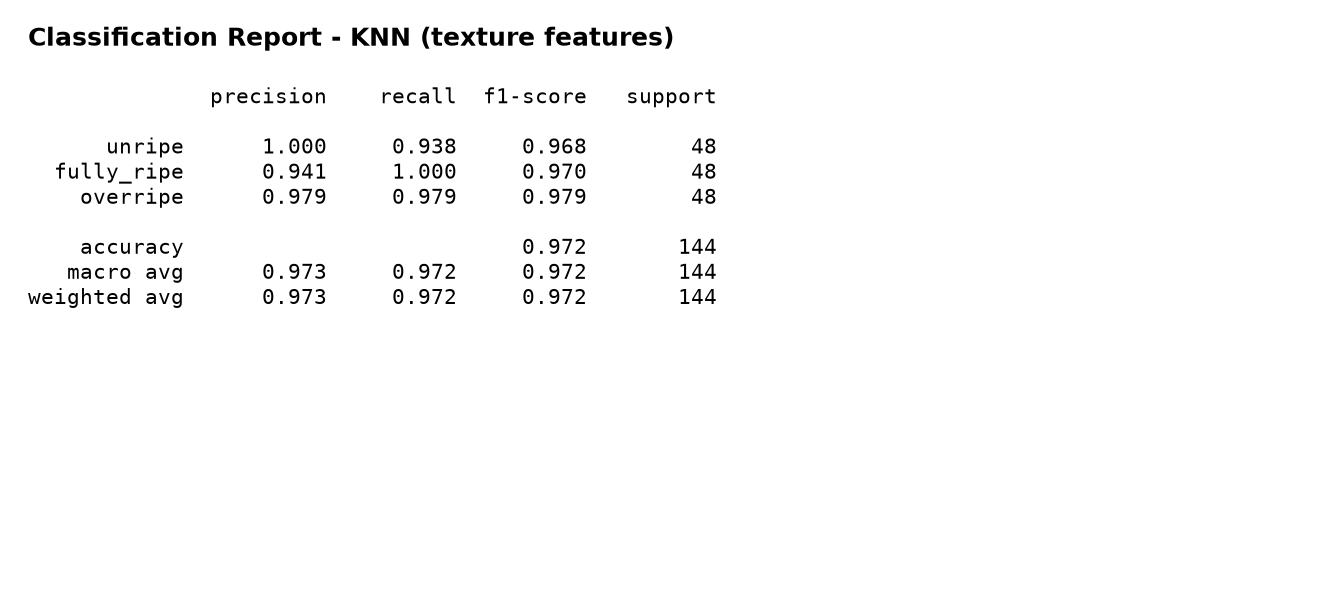

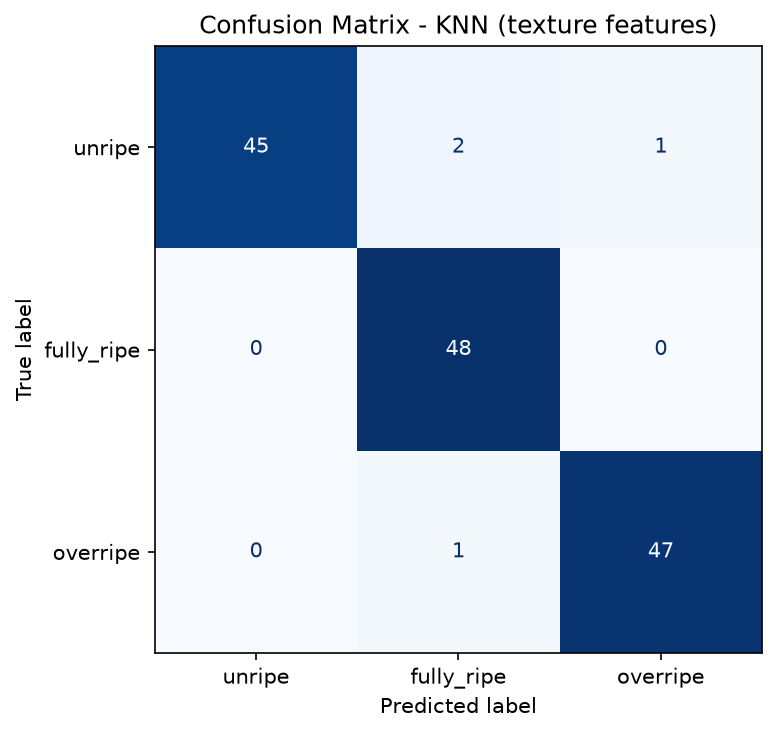

In [13]:
best_name = max(results, key=lambda k: (results[k]['accuracy'], results[k]['macro_f1']))
best_model = models[best_name]
print(f"Best classifier: {best_name} "
      f"(test accuracy {results[best_name]['accuracy'] * 100:.2f}%)")

# 1) Save model + scaler + metadata (usable by the Streamlit app later)
joblib.dump({'model': best_model, 'scaler': scaler, 'feature_cols': FEATURE_COLS,
             'label_map': LABEL_MAP, 'classifier': best_name},
            OUTPUT_DIR / 'texture_model.joblib')

# 2) Classification report rendered as an image
report_txt = classification_report(y_test, predictions[best_name],
                                   labels=list(LABEL_MAP.values()),
                                   target_names=CLASSES, digits=3)
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axis('off')
ax.text(0.01, 0.98, f'Classification Report - {best_name} (texture features)',
        transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')
ax.text(0.01, 0.88, report_txt, transform=ax.transAxes,
        fontsize=10, family='monospace', va='top')
plt.tight_layout()
report_path = OUTPUT_DIR / 'texture_classification_report.png'
plt.savefig(report_path, dpi=150, bbox_inches='tight')
plt.show()

# 3) Confusion matrix rendered as an image
fig, ax = plt.subplots(figsize=(6.5, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, predictions[best_name]),
                       display_labels=CLASSES).plot(ax=ax, cmap='Blues',
                                                    colorbar=False)
ax.set_title(f'Confusion Matrix - {best_name} (texture features)')
plt.tight_layout()
cm_path = OUTPUT_DIR / 'texture_confusion_matrix.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved: {OUTPUT_DIR / 'texture_model.joblib'}")
print(f"Saved: {report_path}")
print(f"Saved: {cm_path}")

### Step 14: Feature Importance (Random Forest)

Random Forest measures how much each feature contributed to its splits. This tells us *which* texture properties matter most for ripeness — good material for the Discussion section of the report.

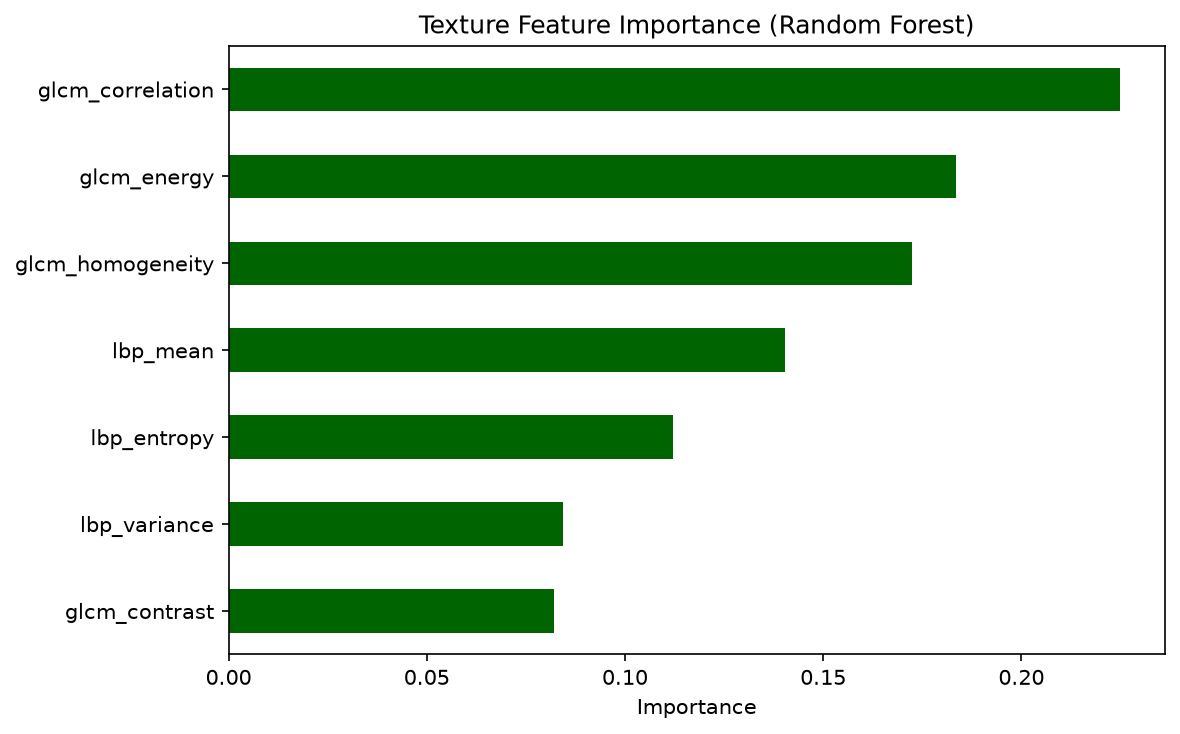

In [14]:
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', color='darkgreen', ax=ax)
ax.set_title('Texture Feature Importance (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### Step 15: Feature Distribution Across Classes

Boxplots (training set) show how each feature varies between the three stages. Features whose boxes barely overlap are the most discriminative — useful visual evidence for the Results section.

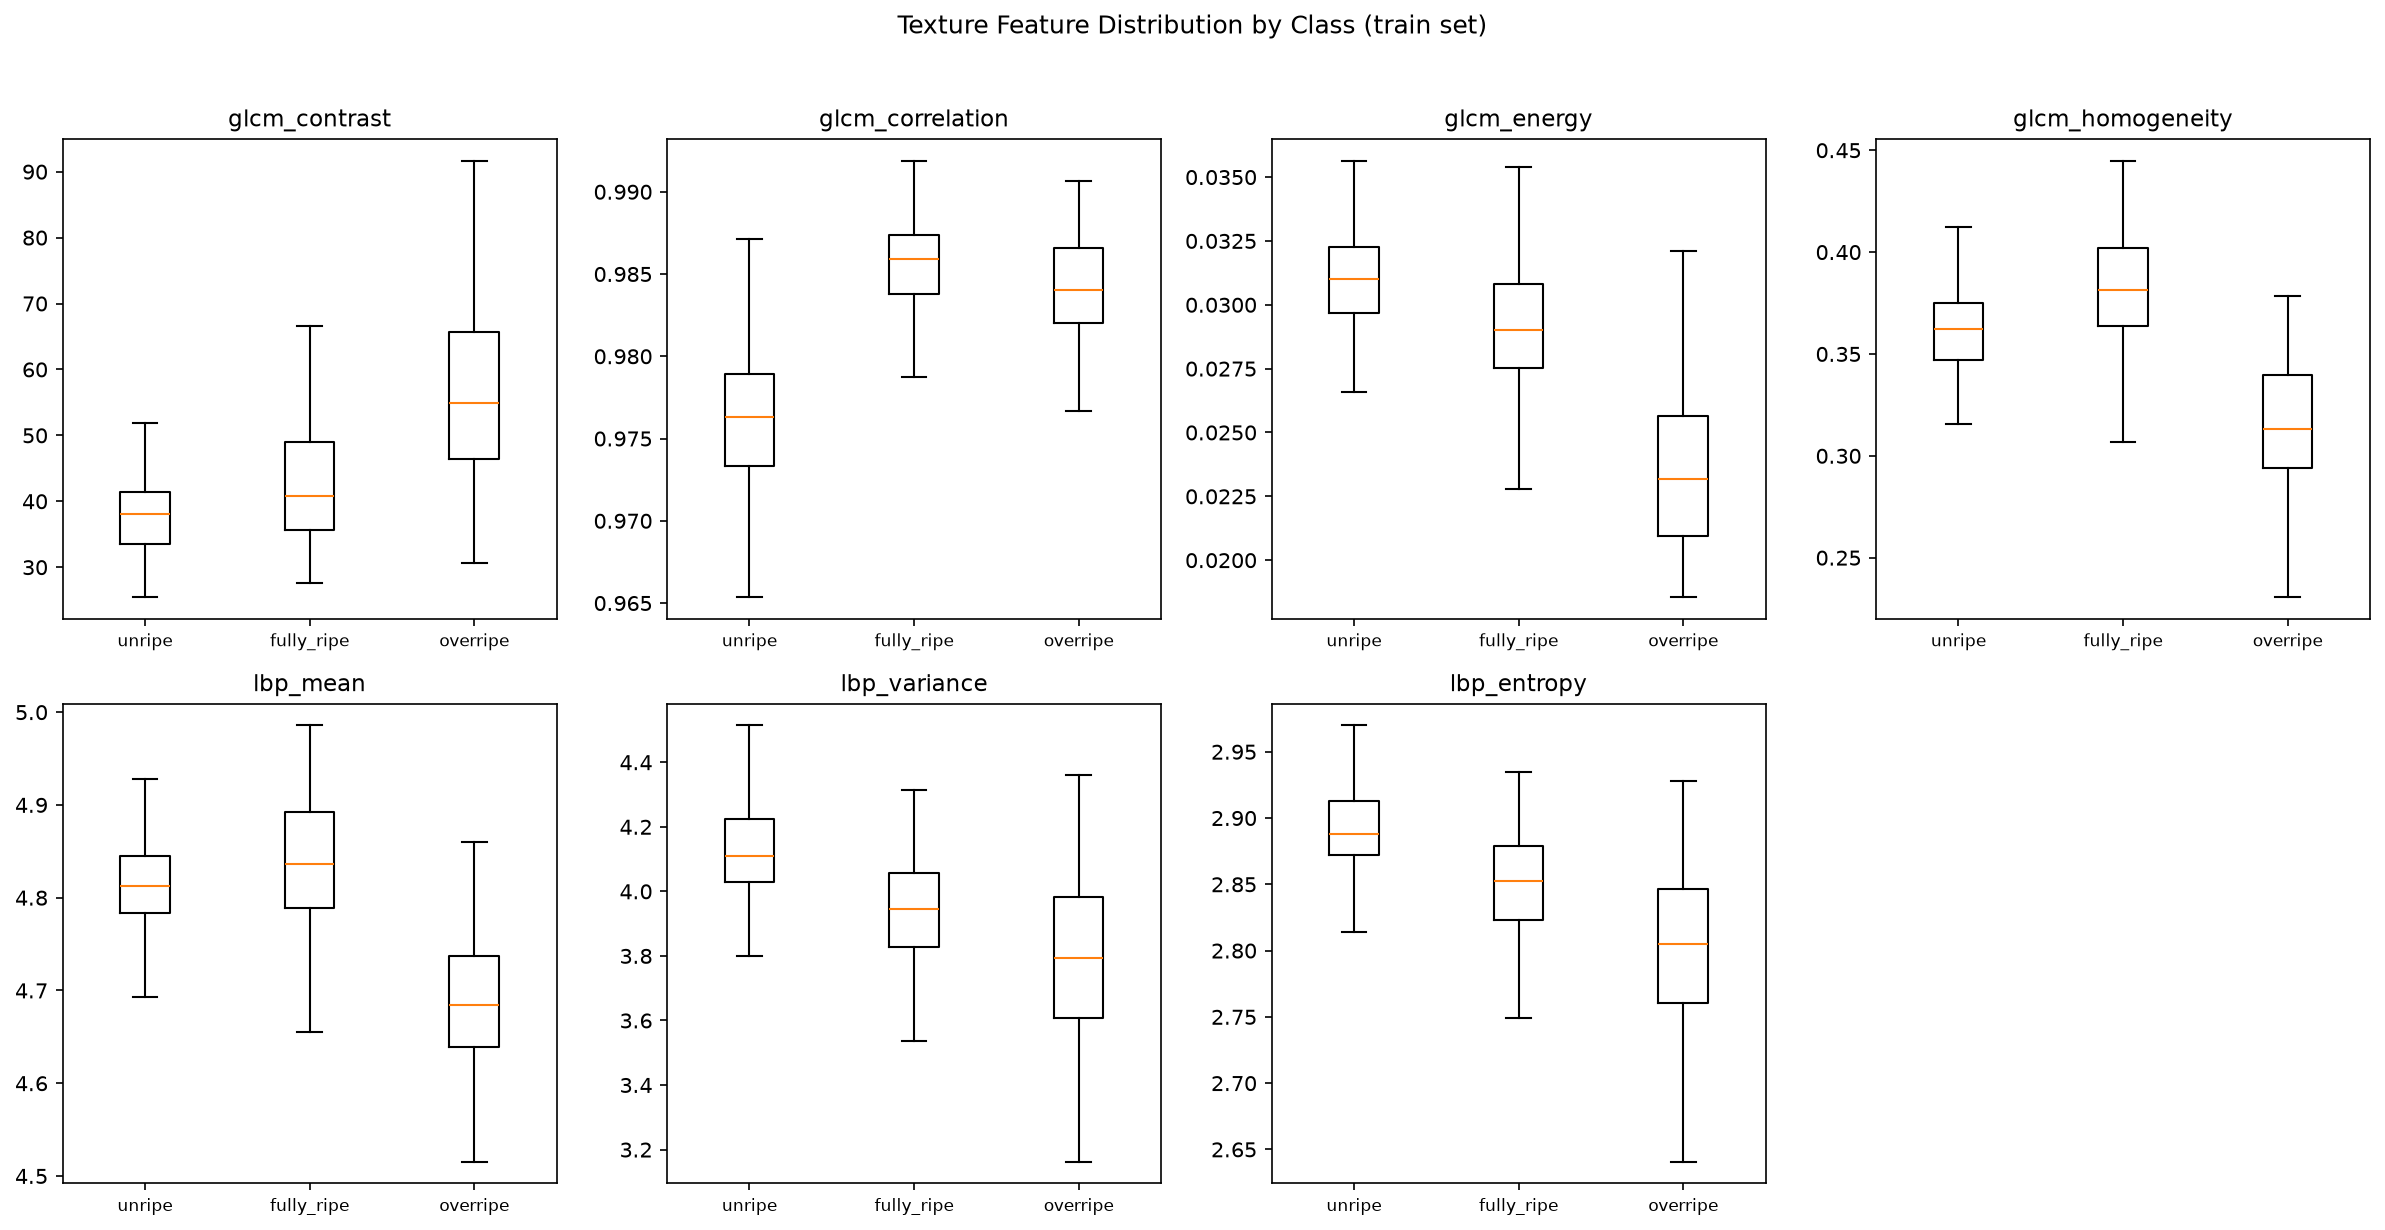

In [15]:
train_df = df[df['train_or_test'] == 'train'].copy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, col in enumerate(FEATURE_COLS):
    data = [train_df.loc[train_df['class'] == cls, col].dropna() for cls in CLASSES]
    axes[i].boxplot(data, showfliers=False)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xticklabels(CLASSES)
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].set_ylabel('')

axes[-1].axis('off')   # 7 features -> the 8th subplot is unused
fig.suptitle('Texture Feature Distribution by Class (train set)', y=1.02)
plt.tight_layout()
plt.show()

### Step 16: Inference Test — Predict on a Single New Image

This simulates the exact pipeline the Streamlit app will use: load the saved model and scaler, run the texture feature extraction on **one** image, and show the prediction in a picture.

It is tested on one sample image from each class — each picture shows the **true** class, the **predicted** class, the confidence, and the processing latency (the project objective requires under 200 ms per image).

Loaded model: KNN  (features: ['glcm_contrast', 'glcm_correlation', 'glcm_energy', 'glcm_homogeneity', 'lbp_mean', 'lbp_variance', 'lbp_entropy'])
[Inference Test] results:
  - true=unripe      predicted=unripe      confidence=80.0% | latency=76.3 ms
  - true=fully_ripe  predicted=fully_ripe  confidence=100.0% | latency=76.9 ms
  - true=overripe    predicted=overripe    confidence=100.0% | latency=91.3 ms


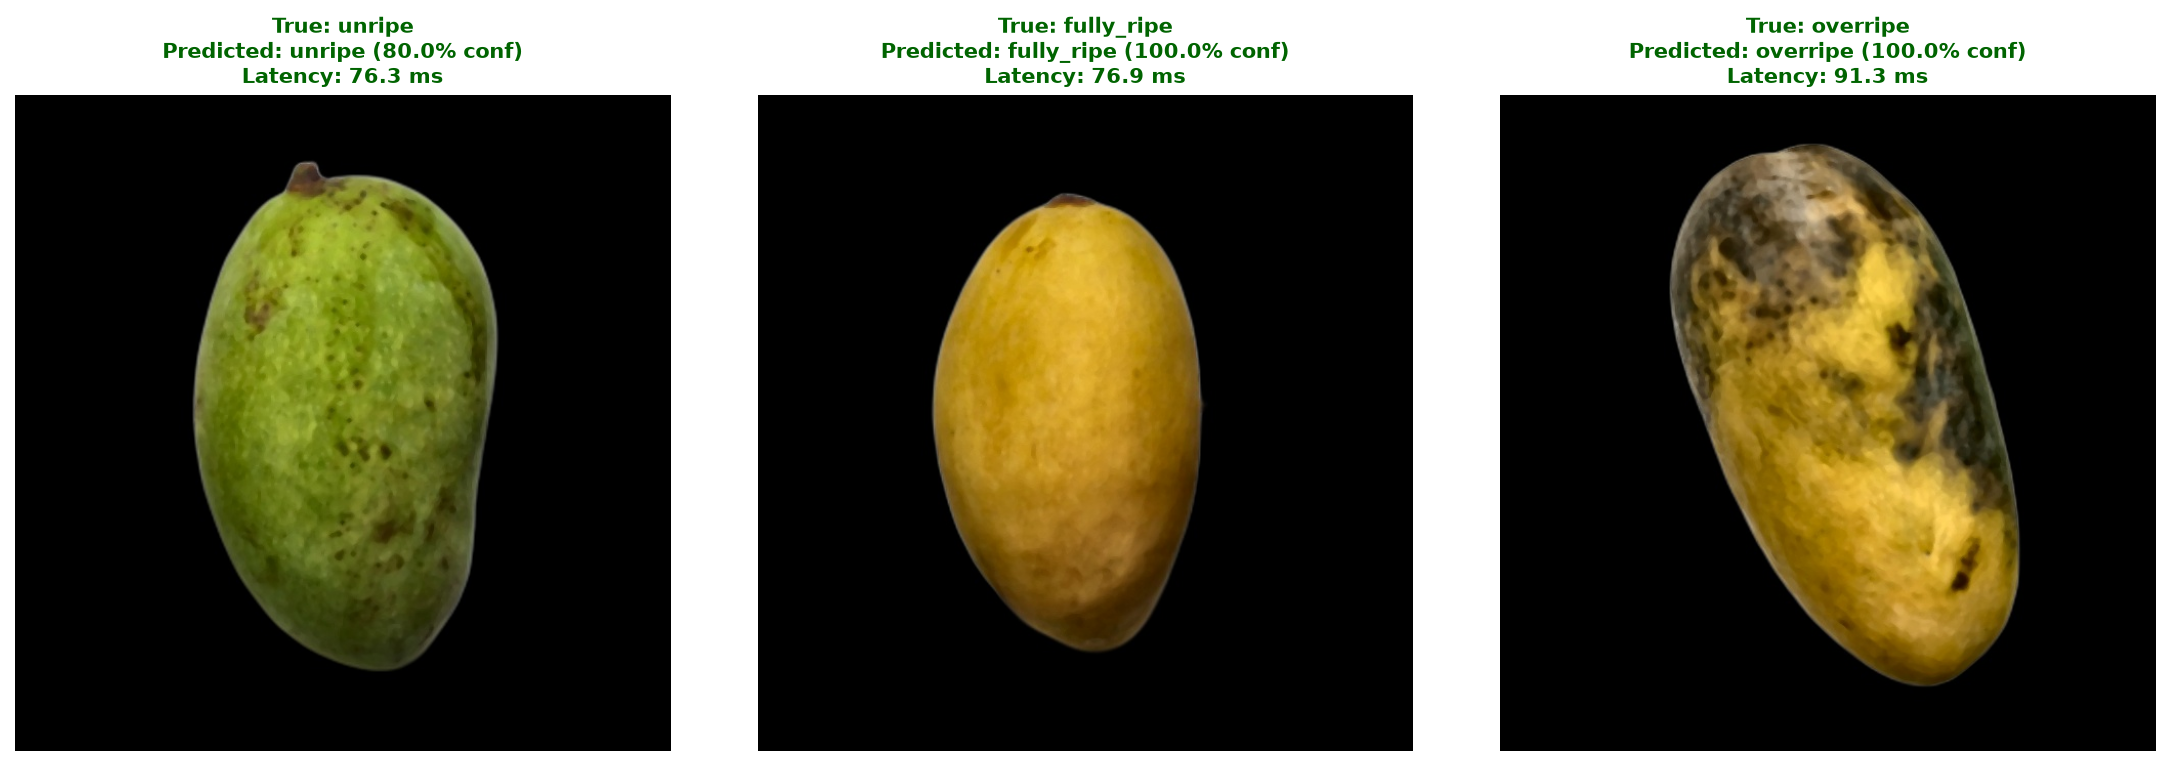

In [16]:
import time

# Load the model package saved in Step 13 (best classifier + scaler)
saved = joblib.load(OUTPUT_DIR / 'texture_model.joblib')
infer_model = saved['model']
infer_scaler = saved['scaler']
infer_cols = saved['feature_cols']
print(f"Loaded model: {saved['classifier']}  (features: {infer_cols})")


def predict_mango_ripeness(img_path):
    """Full single-image inference: load -> texture features -> scale -> predict."""
    t_start = time.time()

    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        raise ValueError(f"Could not load image: {img_path}")

    feats, _, _ = texture_pipeline(img_bgr)
    feat_row = pd.DataFrame([feats])[infer_cols].values
    scaled = infer_scaler.transform(feat_row)          # same scaler as in training

    pred_label = int(infer_model.predict(scaled)[0])
    pred_class = [c for c, v in LABEL_MAP.items() if v == pred_label][0]

    confidence = float('nan')
    if hasattr(infer_model, 'predict_proba'):
        confidence = float(np.max(infer_model.predict_proba(scaled)[0])) * 100.0

    elapsed_ms = (time.time() - t_start) * 1000.0
    return {'true_class': img_path.parent.name,
            'prediction': pred_class,
            'confidence': confidence,
            'latency_ms': elapsed_ms,
            'image_rgb': cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)}


# Test on one sample image from each class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(15, 5))
results = []
for ax, cls in zip(axes, CLASSES):
    sample = sorted((ROOT / 'test' / cls).glob('*.jpg'))[0]
    res = predict_mango_ripeness(sample)
    results.append((cls, res))

    ax.imshow(res['image_rgb'])
    correct = res['prediction'] == res['true_class']
    ax.set_title(f"True: {res['true_class']}\n"
                 f"Predicted: {res['prediction']} ({res['confidence']:.1f}% conf)\n"
                 f"Latency: {res['latency_ms']:.1f} ms",
                 fontsize=10, fontweight='bold',
                 color='darkgreen' if correct else 'darkred')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("[Inference Test] results:")
for true_cls, res in results:
    print(f"  - true={true_cls:11s} predicted={res['prediction']:11s} "
          f"confidence={res['confidence']:.1f}% | latency={res['latency_ms']:.1f} ms")

### Summary

Run all cells (Cell ▸ Run All) and you will get:

| Output | Contents |
|---|---|
| `output/texture_based/texture_features.csv` | 715 rows × 10 columns (filename, class, train_or_test, 7 features) |
| `output/texture_based/texture_model.joblib` | best classifier + scaler + parameters |
| `output/texture_based/texture_classification_report.png` | report of the best classifier |
| `output/texture_based/texture_confusion_matrix.png` | confusion matrix of the best classifier |


The final section (**Step 16**) also demonstrates a single-image **inference test**: it loads the saved model and predicts the ripeness of sample mango images, showing each result as a picture — the same flow the Streamlit app will use.
The companion file **`texture_analysis_plan_kb.md`** (in this folder) explains every step in detail — the theory, the parameters, and how to write this up for the assignment.